# ML Research Benchmarking: Adaptive Edge–Cloud Smart-Grid EMS

This notebook demonstrates the **research-engineering workflow** behind the project: causal feature engineering, model baselines, rolling time-series validation, ablation studies, anomaly-detector comparison, and model efficiency trade-offs.

> The data are synthetic and the results validate the software/experimental workflow only.

## Research questions

1. Do learned forecasting models beat a persistence baseline?
2. Which model offers the best accuracy/latency/model-size trade-off?
3. How stable are results across rolling time windows?
4. Which feature groups materially affect forecasting?
5. Which unsupervised anomaly detector performs best on held-out injected anomalies?

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from smartgrid_ems.data import generate_synthetic_grid_data
from smartgrid_ems.features import engineer_features
from smartgrid_ems.research import run_research_suite

raw = generate_synthetic_grid_data(rows=2880, anomaly_rate=0.04, seed=42)
data = engineer_features(raw)
print(f"Rows after causal feature engineering: {len(data):,}")
data.head()

Rows after causal feature engineering: 2,876


,timestamp,load_kw,renewable_kw,temperature_c,solar_irradiance_wm2,wind_speed_ms,voltage_pu,frequency_hz,battery_soc,communication_latency_ms,message_frequency_hz,device_state_transition,is_anomaly,hour_sin,hour_cos,day_of_week,load_lag_1,load_lag_4,load_rolling_4,load_rate_of_change,power_deviation_kw
0,2025-01-01 01:00:00+00:00,265.995444,57.088729,7.346041,0.000000,4.757394,0.997868,50.037974,0.425000,38.956259,4.148534,0,0,0.258819,0.965926,2,237.978944,270.563846,260.579551,-15.016222,180.890215
1,2025-01-01 01:15:00+00:00,256.033179,66.523966,8.200448,9.104007,5.376757,0.998198,50.037899,0.411107,23.015731,4.271749,0,0,0.321439,0.946930,2,265.995444,280.780246,259.437450,28.016500,199.471479
2,2025-01-01 01:30:00+00:00,258.441325,59.494151,10.260202,15.345411,4.676513,1.005704,50.044005,0.397810,28.035353,4.100592,0,0,0.382683,0.923880,2,256.033179,252.995166,253.250683,-9.962266,196.539027
3,2025-01-01 01:45:00+00:00,266.702262,88.374578,9.542765,4.249701,7.286637,1.008292,50.013182,0.385164,28.284083,3.898928,0,0,0.442289,0.896873,2,258.441325,237.978944,254.612223,2.408146,170.066747
4,2025-01-01 02:00:00+00:00,254.576251,62.655776,9.974798,0.000000,5.221315,1.000426,49.982973,0.373223,25.734934,3.807327,0,0,0.500000,0.866025,2,266.702262,265.995444,261.793053,8.260937,204.046486


## Run reproducible research suite

In [2]:
output_dir = ROOT / "reports" / "research_notebook"
summary = run_research_suite(data, output_dir, seed=42, include_lstm=False)
print("Best holdout forecaster:", summary["best_forecast_model"]["model"])
print("Best anomaly detector:", summary["best_anomaly_detector"]["detector"])

Best holdout forecaster: hist_gradient_boosting
Best anomaly detector: one_class_svm


## Forecast baselines and efficiency

In [3]:
forecast = pd.DataFrame(summary["forecast_benchmarks"])
forecast[["model", "mae_kw", "rmse_kw", "r2", "inference_ms_per_sample", "serialized_size_kb"]].sort_values("mae_kw")

,model,mae_kw,rmse_kw,r2,inference_ms_per_sample,serialized_size_kb
4,hist_gradient_boosting,13.269018,22.497112,0.832980,0.007534,720.645508
3,extra_trees,13.689449,25.839527,0.779665,0.088300,24054.208008
2,random_forest,13.790870,26.317228,0.771443,0.044330,1502.056641
1,ridge,17.076446,29.829383,0.706368,0.000980,1.753906
0,persistence_lag1,21.397684,42.238841,0.411240,0.000000,0.000000


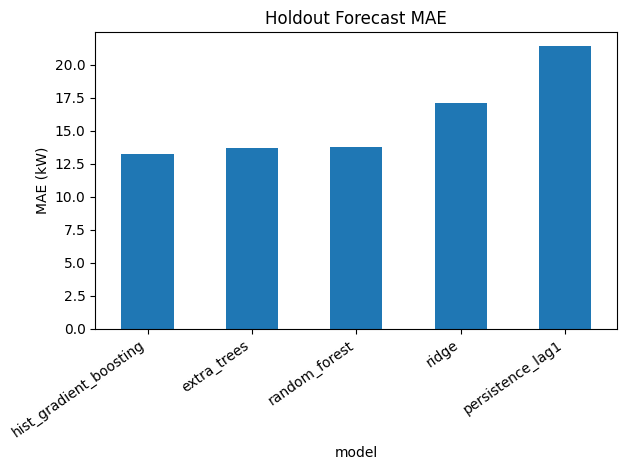

In [4]:
ax = forecast.sort_values("mae_kw").plot.bar(x="model", y="mae_kw", legend=False, title="Holdout Forecast MAE")
ax.set_ylabel("MAE (kW)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

## Rolling-origin backtest

In [5]:
backtest = pd.DataFrame(summary["time_series_backtest"])
backtest.sort_values("mae_mean_kw")

,model,folds,mae_mean_kw,mae_std_kw,rmse_mean_kw,rmse_std_kw,r2_mean,r2_std
1,random_forest,4,13.677358,0.150854,24.702549,1.344902,0.775527,0.015091
2,hist_gradient_boosting,4,13.906553,0.347674,22.588138,0.705481,0.811642,0.016624
0,ridge,4,16.045813,0.618720,26.786312,1.898036,0.736365,0.020685


A single holdout can favor a model for one period. Rolling-origin validation tests whether conclusions remain stable across multiple future windows.

## Feature ablation

In [6]:
ablation = pd.DataFrame(summary["ablation_study"])
ablation[["experiment", "n_features", "mae_kw", "rmse_kw", "r2"]].sort_values("mae_kw")

,experiment,n_features,mae_kw,rmse_kw,r2
0,full_features,18,13.689449,25.839527,0.779665
2,no_grid_state_features,13,13.689767,26.272589,0.772218
1,no_temporal_features,11,14.007188,26.567559,0.767074
3,no_communication_features,15,14.538841,29.906970,0.704839


## Feature importance

In [7]:
importance = pd.DataFrame(summary["feature_importance"]).head(10)
importance

,feature,importance
0,load_rolling_4,0.297628
1,load_lag_1,0.181117
2,hour_sin,0.125132
3,hour_cos,0.065612
4,battery_soc,0.054124
5,power_deviation_kw,0.053012
6,load_lag_4,0.050073
7,solar_irradiance_wm2,0.040271
8,communication_latency_ms,0.039985
9,message_frequency_hz,0.026235


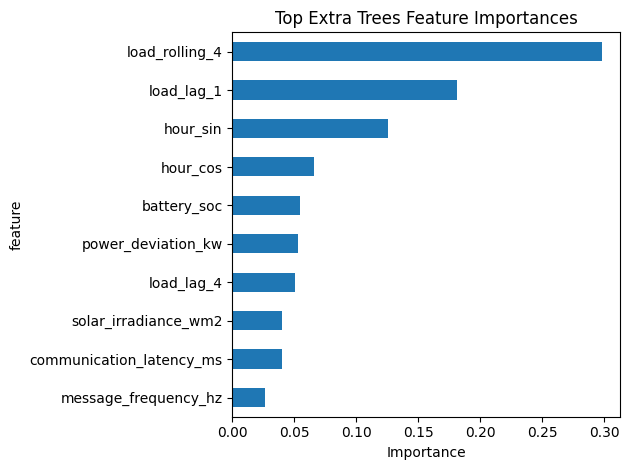

In [8]:
ax = importance.sort_values("importance").plot.barh(x="feature", y="importance", legend=False, title="Top Extra Trees Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()

## Anomaly-detector comparison

In [9]:
anomaly = pd.DataFrame(summary["anomaly_benchmarks"])
anomaly.sort_values("f1", ascending=False)

,detector,precision,recall,f1,predicted_anomaly_rate
2,one_class_svm,0.315789,1.000000,0.480000,0.131944
1,isolation_forest,0.207207,0.958333,0.340741,0.192708
0,statistical,0.109091,1.000000,0.196721,0.381944


## Interpretation

The project intentionally reports multiple metrics instead of declaring a universal winner. Forecast accuracy, temporal stability, inference latency, model size, and anomaly-detection behavior can favor different methods. That trade-off is central to the edge–cloud design: a small local model can support low-latency inference, while higher-capacity or specialized models can be invoked selectively when uncertainty or abnormal conditions justify escalation.

## Optional deep-learning extension

Install the `deep-learning` extra and run:

```bash
smartgrid-ems research --include-lstm --lstm-epochs 12
```

This adds a compact multivariate PyTorch LSTM to the same benchmark table so its accuracy and footprint can be compared directly against classical baselines.